In [1]:
from detectron2 import model_zoo, engine, config
from transformers import AutoModelForCausalLM
from transformers.models.bert.modeling_bert import BertEmbeddings
from detectron2.data.detection_utils import read_image
import torch
import pdb
import pickle,json,gc,os
import random
from accelerate import infer_auto_device_map

import matplotlib.pyplot as plt

from mic21s import MIC21Summarizer

from pycocoevalcap.bleu.bleu import Bleu
from pycocoevalcap.meteor.meteor import Meteor
from pycocoevalcap.rouge.rouge import Rouge
from pycocoevalcap.cider.cider import Cider
from pycocoevalcap.spice.spice import Spice

In [2]:
cuda_id = 2

In [3]:
device_map = torch.load('llama_3_dm.pth')
device_map['model.embed_tokens'] = 1
device_map['model.norm'] = 2
device_map['model.rotary_emb'] = 2
device_map['lm_head'] = 1
device_map['model.layers.12'] = 2
device_map['model.layers.13'] = 2
device_map['model.layers.14'] = 2
device_map['model.layers.15'] = 2
device_map['model.layers.16'] = 2
device_map['model.layers.17'] = 2
device_map['model.layers.18'] = 2
device_map['model.layers.19'] = 2
device_map['model.layers.20'] = 2
device_map['model.layers.21'] = 2
device_map['model.layers.22'] = 2
device_map['model.layers.23'] = 2
device_map['model.layers.0'] = 1
device_map['model.layers.1'] = 1
device_map['model.layers.2'] = 2
device_map['model.layers.3'] = 2

In [4]:
model = MIC21Summarizer(cuda_id,device_map)

In [5]:
categs = ['cricket','baseball','basketball','volleyball','boxing','beach_volleyball']
categs = ['chess','car_transporter','violinist','motorcycle_racing','tank','baseball','helicopter','police_helicopter','military_helicopter','bicycle_racing','fishing','hunting','handball','makeup_artist','military_truck','spaceship','pickup','skiing','bicycle_racing']

In [6]:
data_gt = {}
loss_hist = {}
for cat in categs:
    with open(f'descriptions/{cat}.pkl', 'rb') as f:
        data_gt[cat] = pickle.load(f)
        loss_hist[cat] = []

In [7]:
names = list(data_gt[cat].keys())
img = read_image(os.path.join(f"downloaded_images/{cat}/data/",names[1]))
out1 = model(img,None)

In [8]:
decoded_text = model.tokenizer.batch_decode(torch.argmax(out1, dim=-1))
decoded_text

['>|>|>|>|>|>|>|>|>|>|>|>|>|>|>|>|>|>|>|>|>|>|>|>|>|>|>|>|>|>|>|>|']

In [11]:
out1.grad

/tmp/ipykernel_28967/2451328268.py:1: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:489.)
  out1.grad


In [25]:
msg = model.tokenizer("Hello",return_tensors="pt")
emb = model.llm.model.embed_tokens(msg["input_ids"])
logits = model.llm.lm_head(emb)
toks = torch.argmax(logits[:,-1],dim=-1)
model.tokenizer.decode(toks)

'chner'

In [24]:
#Test model generation
from transformers import OffloadedCache

msg = ("Who you are ?")
msg_tok = model.tokenizer(msg,return_tensors="pt")
with torch.no_grad():
    emb = model.llm.model.embed_tokens(msg_tok["input_ids"])

    cache = OffloadedCache()

    outputs = model.llm(inputs_embeds=emb,past_key_values=cache,use_cache=True)
    logits = outputs.logits[:,-1]
    out_logits = logits.unsqueeze(0)
    last_position_id = emb.shape[1] - 1
    new_tok = torch.argmax(logits,dim=-1)

    for k in range(0,1024):
        position_ids = torch.tensor([[last_position_id + 1]], device=emb.device)
        last_position_id += 1
        outputs = model.llm(input_ids=new_tok.unsqueeze(0), 
                           past_key_values=cache,
                           use_cache=True,
                           position_ids=position_ids)
        logits = outputs.logits[:,-1]
        new_tok = torch.argmax(logits,dim=-1)
        if new_tok.item() == model.tokenizer.eos_token_id:
            break
        out_logits = torch.cat([out_logits,logits.unsqueeze(0)],dim=1)

    toks = torch.argmax(out_logits,dim=-1)
    print(model.tokenizer.batch_decode(toks))

['\nI am a writer, a poet, a storyteller, a dreamer, a lover of words, a lover of life.\nI am a dreamer, a lover of words, a lover of life.\nI am a writer, a poet, a storyteller, a dreamer, a lover of words, a lover of life.\nI am a writer, a poet, a storyteller, a dreamer, a lover of words, a lover of life.\nI am a writer, a poet, a storyteller, a dreamer, a lover of words, a lover of life.\nI am a writer, a poet, a storyteller, a dreamer, a lover of words, a lover of life.\nI am a writer, a poet, a storyteller, a dreamer, a lover of words, a lover of life.\nI am a writer, a poet, a storyteller, a dreamer, a lover of words, a lover of life.\nI am a writer, a poet, a storyteller, a dreamer, a lover of words, a lover of life.\nI am a writer, a poet, a storyteller, a dreamer, a lover of words, a lover of life.\nI am a writer, a poet, a storyteller, a dreamer, a lover of words, a lover of life.\nI am a writer, a poet, a storyteller, a dreamer, a lover of words, a lover of life.\nI am a wr

In [25]:
model.tokenizer

LlamaTokenizerFast(name_or_path='TinyLlama/TinyLlama-1.1B-Chat-v1.0', vocab_size=32000, model_max_length=2048, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '</s>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [10]:
emb1 = torch.cat([emb, model.llm.model.embed_tokens(toks).unsqueeze(0)],dim=1)
out1 = model.llm(inputs_embeds=emb1)
logits = out1.logits
toks = torch.argmax(logits[:,-1],dim=-1)
model.tokenizer.decode(toks)

'ure'

In [35]:
model.load_state_dict(torch.load('model_2.pth'))

<All keys matched successfully>

In [15]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"Parameter name: {name}")
        print(f"Shape: {param.shape}")
        print(f"Requires grad: {param.requires_grad}")
        print(f"Values: {param.data}")
        print('-' * 40)

Parameter name: projection_layer.weight
Shape: torch.Size([4096, 256])
Requires grad: True
Values: tensor([[ 0.0308, -0.0192, -0.0050,  ...,  0.0384, -0.0528, -0.0613],
        [-0.0401, -0.0054, -0.0601,  ..., -0.0324,  0.0567, -0.0186],
        [-0.0441, -0.0005,  0.0168,  ...,  0.0328, -0.0266, -0.0354],
        ...,
        [ 0.0139, -0.0513, -0.0532,  ...,  0.0500, -0.0056, -0.0474],
        [ 0.0188, -0.0517,  0.0055,  ..., -0.0597,  0.0612,  0.0073],
        [ 0.0470,  0.0574,  0.0237,  ...,  0.0109,  0.0614, -0.0443]],
       device='cuda:1')
----------------------------------------
Parameter name: projection_layer.bias
Shape: torch.Size([4096])
Requires grad: True
Values: tensor([ 0.0607,  0.0545, -0.0217,  ...,  0.0604, -0.0401, -0.0431],
       device='cuda:1')
----------------------------------------
Parameter name: projection_norm.weight
Shape: torch.Size([256])
Requires grad: True
Values: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
    

In [8]:
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
num_epochs = 1000

toggle = False
for epoch in range(num_epochs):
    for cat in categs[:1]:
        epoch_loss = 0
        for (ind,fn) in enumerate(data_gt[cat].keys()):
            try:
                data_struct = json.loads(data_gt[cat][fn])
                target = model.tokenizer(data_struct["Title"]+"<|eot_id|>",return_tensors="pt")
                target_ids = target["input_ids"][:,1:64]
                img = read_image(os.path.join(f"downloaded_images/{cat}/data/",fn))
            except:
                continue
            out1 = model(img,target_ids.shape[1])
            loss = torch.nn.CrossEntropyLoss()(out1.permute((0,2,1)), target_ids.cuda(model.out_device))
            #else:
            #    out1 = model(img,target["input_ids"][:,:-1].cuda(cuda_id))
            #    loss = torch.nn.CrossEntropyLoss()(out1.permute((0,2,1)), target["input_ids"][:,1:].cuda(cuda_id))
            #toggle = not toggle
        
            optimizer.zero_grad()
            loss.backward()
            #torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()/len(data_gt[cat].keys())
            #if ind > 10:
            #break
        loss_hist[cat].append(epoch_loss)
        decoded_text = model.tokenizer.batch_decode(torch.argmax(out1, dim=-1))
        print(decoded_text)
        print(f"Epoch [{epoch+1}/{num_epochs}], Category: {cat}, Loss: {epoch_loss}")

['ot||e||||e|||id||||||||||||']
Epoch [1/1000], Category: chess, Loss: 5.5974984975961535
['|||||||||||||||||||||||||']
Epoch [2/1000], Category: chess, Loss: 4.33914513221154
['essessess Ch Ch Ch<|ee|ot||id|||id|||id||']
Epoch [3/1000], Category: chess, Loss: 3.969771634615386
['Chusedessessess Ch Ch Focused|ee|||||id||||||']
Epoch [4/1000], Category: chess, Loss: 3.7519831730769235
['Fusedessess Ch Ch<|ee|||||||||>|id|||']
Epoch [5/1000], Category: chess, Loss: 3.5910456730769247
['Focusedessessess<|ee|||otid||>|>id||>|']
Epoch [6/1000], Category: chess, Loss: 3.4240159254807714
['Foc Chessess Chess Ch<ess<eee|||||id_|>||']
Epoch [7/1000], Category: chess, Loss: 3.300450721153847
['Focressessess Chess<<eeee||||>|>|id|>']
Epoch [8/1000], Category: chess, Loss: 3.215944260817307
['Focused Chessessessating a<|ot|ot|||>|>id|>|>']
Epoch [9/1000], Category: chess, Loss: 3.1068359375000005
['Ch Conessessess Contemplating a<<|ote||||>id|>|>|']
Epoch [10/1000], Category: chess, Loss: 3.072934

KeyboardInterrupt: 

In [10]:
torch.save(model.projection_layer.state_dict(), f'model_chess_title_1.pth')
torch.save(model.projection_norm.state_dict(), f'model_chess_title_2.pth')
torch.save(loss_hist,f'model_chess_title_loss.pth')

In [15]:
with torch.no_grad():
    for cat in categs[:1]:
        for (ind,fn) in enumerate(data_gt[cat].keys()):
            try:
                data_struct = json.loads(data_gt[cat][fn])
                img = read_image(os.path.join(f"downloaded_images/{cat}/data/",fn))
            except:
                continue
            out1 = model(img,None)
            decoded_text = model.tokenizer.batch_decode(torch.argmax(out1, dim=-1))
            print(decoded_text)

['Focused Young Chess Player Contemplates a Game<|eot_id|>>>||>>id|>||>id|>_id|>>>|>|>id|>>>|>id|>>eot_id|>>>']
['Chess Player Observing Robotic Arm<|eot_id|>>>|>|>|>eot_id||>|>|>eot_|>|>|>e_|>|>>eot_|>|>>eot_|']
['Intense Chess Strategy: A Moment of Consideration<|eot_id|>|>>|>|eot_id||>||eot_id|>|>|>id|>|>eot_idid|>>|>id|']
['Concentrated Chess Strategist - Analyzing the Board<|eot_id|>>>>>|eot_id|>>>>>|>id|>>>>id|>>>>>_|>|>id|>>>_']
['Focused Young Chess Player Contemplating a Game<|eot_id|>>>>>>>|>e_id|>>>>|>|>idid|>>>>idid|>>>eot_||>ididid>>']
['Chess Grandmasters in In Inten Focus<|eot_id|>>>>>>id|>>id||eot_id|>>>>id|||>eot_|>|>>th<|eeidxid|||']
['Chess Player Concentrating on a Chessboard<|eot_id|>>>>id|>|>>eot_id|>|>>id|>|>>>|eot_id|>>>>|eot_id|>>>>']
['Intense Chess Strategy: A Focused Player<|eot_id|>>>>|eot_id|>|>_eeotid|>|>|eeot_||>|eeeot_|>|>|eot_']
['Chess Player in a Tournament Setting - Warsaw 2023<|eot_id|>>>|>eot_id|eot_id|>>>|eotid|>|id|>>eot_id|>e|e|>id|']
['Chess P

KeyboardInterrupt: 

TypeError: unhashable type: 'dict'

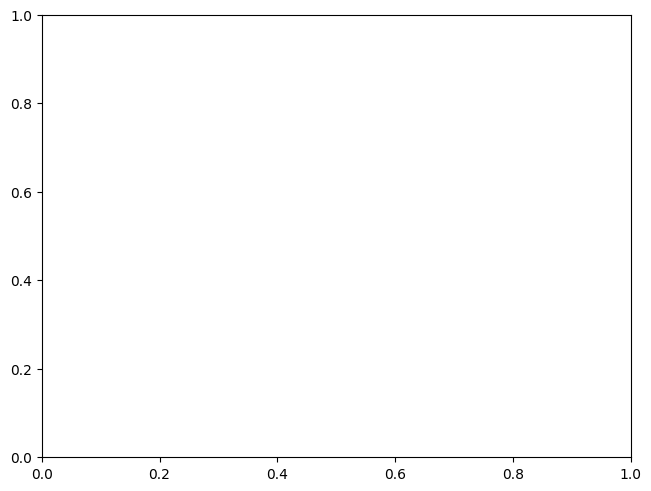

In [12]:
loss_hist = torch.load("model_chess_title_loss.pth")
fig, ax = plt.subplots(layout='constrained')
ax.plot(loss_hist)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.grid()
fig.savefig("training1.png")